##### Generated trained 5 times discriminator


In [1]:
import os
import random
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import HTML
import torchvision.utils as vutils
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
from torchvision.utils import save_image
import matplotlib.animation as animation
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

# Set random seed for reproducibility
manualSeed = 37
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)

Using device:  cuda


##### Load data


In [2]:
path = os.path.join(os.getcwd(), "data", "animals")
image_size = 128
batch_size = 128 # Suggested from paper
num_workers = 8  # number of CPU cores/2
# mean and std dev values are calculated for animals dataset
mean = torch.tensor([0.50869316, 0.50057036, 0.44047505])
std = torch.tensor([0.20191325, 0.19737212, 0.20100889])
transform = transforms.Compose(
    [
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)
train_data = datasets.ImageFolder(root=path, transform=transform)
train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
# We are not spliting train and test data like conventional machine learning for calculating accuracy.
print("Mean: ", mean.cpu().numpy(), "Std dev: ", std.cpu().numpy())

Mean:  [0.50869316 0.50057036 0.44047505] Std dev:  [0.20191325 0.19737212 0.20100889]


In [3]:
n_channels = 3  # RGB
z_latent = 100
fg = 128  # size of feature maps in generator
fd = 128  # size of feature maps in discriminator
n_epochs = 100 # number of epochs
beta1 = 0.5  # beta1 value for Adam optimizer Given in Paper
lr = 2e-4  # Learning rate for Adam optimizer Given in Paper
n_generator = 5  # number of training steps for discriminator per iter

# function to initialize weights for any object
def weights_init(c):
    if isinstance(c, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
        nn.init.normal_(c.weight.data, 0.0, 0.02)
        if c.bias is not None:
            nn.init.constant_(c.bias.data, 0)


In [4]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            self.block(z_latent, fg * 8, 4, 1, 0),
            self.block(fg * 8, fg * 4, 4, 2, 1),
            self.block(fg * 4, fg * 2, 4, 2, 1),
            self.block(fg * 2, fg, 4, 2, 1),
            self.block(fg , fg//2, 4, 2, 1),
            nn.ConvTranspose2d(fg//2, n_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def block(self, in_channels, out_channels, kernal_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, out_channels, kernal_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
        )
    def forward(self, z):
        return self.main(z)




class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            self.block(n_channels, fd, 4, 2, 1),
            self.block(fd, fd * 2, 4, 2, 1),
            self.block(fd * 2, fd * 4, 4, 2, 1),
            self.block(fd * 4, fd * 8, 4, 2, 1),
            self.block(fd * 8, fd * 16, 4, 2, 1),
            nn.Conv2d(fd * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )
    def block(self, in_channels, out_channels, kernal_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernal_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, z):
        return self.main(z)
    
gen = Generator().to(device)
dis = Discriminator().to(device)

gen.apply(weights_init)
dis.apply(weights_init)

# Function to test the architecture of the generator and discriminator
def test():
    N, in_channels, H, W = 128, 3, 128, 128
    x = torch.randn((N, in_channels, H, W))  # 64,3,128,128
    disc = Discriminator()
    assert disc(x).shape == (N, 1, 1, 1), "Discriminator test failed"
    gen = Generator()
    z = torch.randn((N, z_latent, 1, 1))
    assert gen(z).shape == (N, in_channels, H, W), "Generator test failed"
    print("All architectural tests passed")
test()

All architectural tests passed


In [5]:
img_list = []
G_losses = []
D_losses = []
iters = 0
fixed_sample = torch.randn(64, z_latent, 1, 1, device=device)  # Ensure 64 images
writer = SummaryWriter("logs/dcgan_shivam")
criterion = nn.BCELoss() # Vanilla GAN loss
optimizer_gen = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_dis = torch.optim.Adam(dis.parameters(), lr=lr, betas=(beta1, 0.999))
print("Training starts ...")
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader, 0):
        ############################
        ## Discriminator Training ##
        ############################
        # Importing real images data. data[0] means images
        real_data = data[0].to(device)
        batch_size = real_data.size(0)
        
        dis.zero_grad()
        # Giving real data to discriminator
        discriminator_output_real = dis(real_data).view(-1)
        error_dis_real = criterion(discriminator_output_real,  torch.full_like(discriminator_output_real, 0.9))
        error_dis_real.backward()
        nn.utils.clip_grad_value_(dis.parameters(), 0.1)
        # D(X) for real data will be mean of output of all data in batch of this iteration
        D_x = discriminator_output_real.mean().item()
        # Training with fake data, Sampling from normal distribution P_z(z)
        sample = torch.randn(batch_size, z_latent, 1, 1, device=device)
        # Input this sampled data to generator
        generator_output = gen(sample)

        # Giving fake data to discriminator
        discriminator_output_fake = dis(generator_output.detach()).view(-1)
        error_dis_fake = criterion(discriminator_output_fake,  torch.full_like(discriminator_output_fake, 0.1))
        error_dis_fake.backward()
        # Gradient clipping applied to discriminator
        nn.utils.clip_grad_value_(dis.parameters(), 0.1)
        # D(G(z)) for fake data will be mean of output of all data in batch of this iteration
        D_G_z1 = discriminator_output_fake.mean().item()
        # Discriminator Total Loss
        error_dis = error_dis_real + error_dis_fake
        optimizer_dis.step()
        
        ########################
        ## Generator Training ##
        ########################
        for _ in range(n_generator): #  Generator training for n_generator times
            gen.zero_grad()
            # Giving fake data to discriminator
            generator_output = gen(sample)
            # Giving fake data to discriminator
            discriminator_output_fake = dis(generator_output).view(-1)
            # Binary cross entropy for generator
            error_gen = criterion(discriminator_output_fake,  torch.full_like(discriminator_output_fake, 0.9))
            # Backpropogation for generator
            error_gen.backward()
            # Gradient clipping applied to generator
            nn.utils.clip_grad_value_(gen.parameters(), 0.1)
            optimizer_gen.step()
            # D(G(z)) for fake data will be mean of output of all data in batch of this iteration
            D_G_z2 = discriminator_output_fake.mean().item()

        if i % 100 == 0:
            print(
                "[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f"
                % (
                    epoch,
                    n_epochs,
                    i,
                    len(train_loader),
                    error_dis.item(),
                    error_gen.item(),
                    D_x,
                    D_G_z1,
                    D_G_z2,
                )
            )

        # Generator and Discriminator Losses
        G_losses.append(error_gen.item())
        D_losses.append(error_dis.item())

        if (iters % 100 == 0) or (
            (epoch == n_epochs - 1) and (i == len(train_loader) - 1)
        ):
            fake = gen(fixed_sample).detach().cpu()
            img_list.append(vutils.make_grid(fake, nrow=8, padding=2, normalize=True))
        iters += 1
print("Training ends ...")
torch.save(dis, f"{n_generator}_critic discriminator.pth")
torch.save(gen, f"{n_generator}_critic generator.pth")
writer.close()

Training starts ...
[0/100][0/43]	Loss_D: 1.3832	Loss_G: 0.4710	D(x): 0.5101	D(G(z)): 0.5077 / 0.6705
[1/100][0/43]	Loss_D: 1.3211	Loss_G: 0.8689	D(x): 0.4821	D(G(z)): 0.4349 / 0.4033
[2/100][0/43]	Loss_D: 1.3746	Loss_G: 0.6757	D(x): 0.4907	D(G(z)): 0.4816 / 0.5113
[3/100][0/43]	Loss_D: 1.3734	Loss_G: 0.6966	D(x): 0.5118	D(G(z)): 0.5031 / 0.4980
[4/100][0/43]	Loss_D: 1.3910	Loss_G: 0.7222	D(x): 0.4711	D(G(z)): 0.4716 / 0.4825
[5/100][0/43]	Loss_D: 1.3906	Loss_G: 0.7092	D(x): 0.4954	D(G(z)): 0.4976 / 0.4902
[6/100][0/43]	Loss_D: 1.3893	Loss_G: 0.6858	D(x): 0.5047	D(G(z)): 0.5063 / 0.5047
[7/100][0/43]	Loss_D: 1.3971	Loss_G: 0.6775	D(x): 0.5054	D(G(z)): 0.5118 / 0.5099
[8/100][0/43]	Loss_D: 1.3976	Loss_G: 0.6714	D(x): 0.5092	D(G(z)): 0.5158 / 0.5138
[9/100][0/43]	Loss_D: 1.3898	Loss_G: 0.6840	D(x): 0.5001	D(G(z)): 0.5022 / 0.5058
[10/100][0/43]	Loss_D: 1.3903	Loss_G: 0.6864	D(x): 0.4999	D(G(z)): 0.5024 / 0.5043
[11/100][0/43]	Loss_D: 1.3913	Loss_G: 0.6846	D(x): 0.4991	D(G(z)): 0.5021 / 0

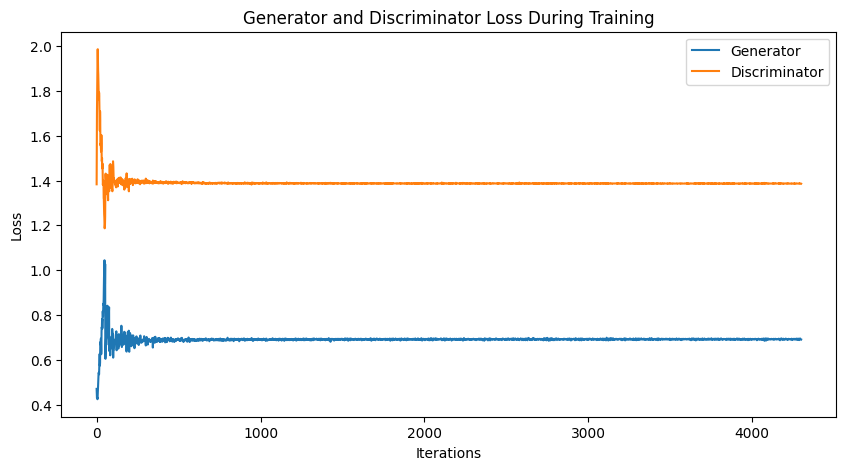

In [6]:
with torch.no_grad():
    fake = gen(fixed_sample).detach().cpu()
gen_img = vutils.make_grid(img_list[-1], nrow=10, padding=2, normalize=True)

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

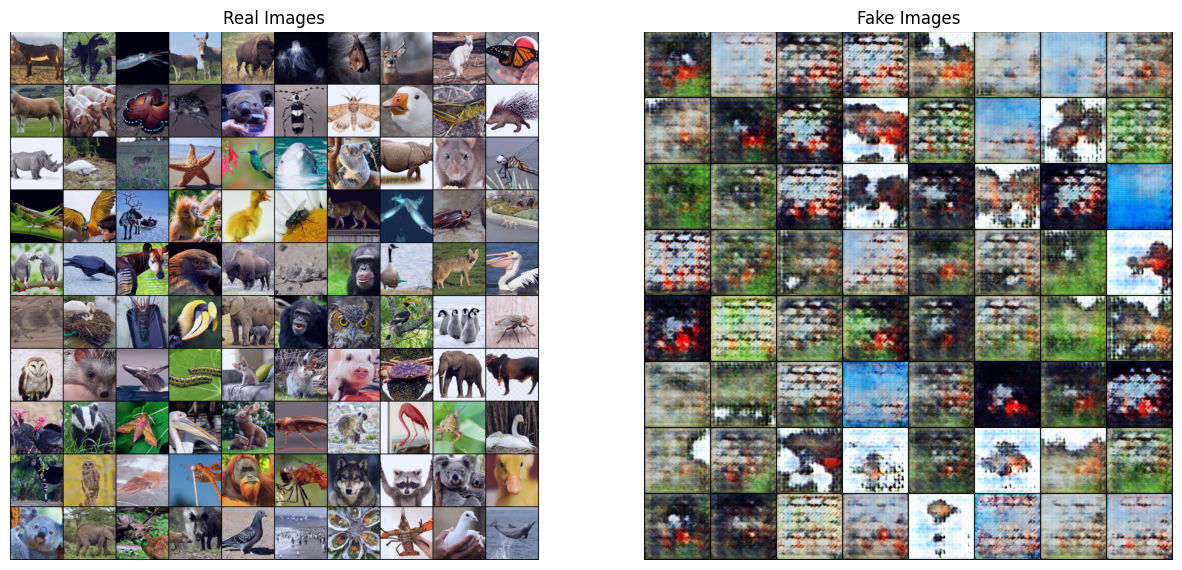

In [7]:
real_batch = next(iter(train_loader))

# Plot the real images
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(
            real_batch[0].to(device)[:100], nrow=10, padding=2, normalize=True
        ).cpu(),
        (1, 2, 0),
    )
)
# Plot the fake images from the last epoch
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))

plt.show()

In [11]:
import numpy as np
fake_images = []
G = torch.load(f"{n_generator}_critic generator.pth").to(device)
for i in range(1000):
    noise = torch.randn(1, 100, 1, 1).to(device)
    img = G(noise).detach().cpu().numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    fake_images.append(img)
fake_images = np.array(fake_images)
# 1000 real fake_images in tensor format
real_images = []
# sample 1000 images from the training set
for i in range(1000):
    img = train_data[i][0].numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    real_images.append(img)


import torch
from torcheval.metrics import FrechetInceptionDistance

# Assuming you have real and fake images as tensors
# real_images: Tensor of shape (1000, 3, 128, 128)
# fake_images: Tensor of shape (1000, 3, 128, 128)

# Initialize FID metric calculator
fid_metric = FrechetInceptionDistance(feature_dim=2048)  # FID is typically computed using Inception-V3 features with 2048 dimensions
# normalize the images

# Update the FID metric with real and fake images
fid_metric.update(torch.tensor(real_images), is_real=True)
fid_metric.update(torch.tensor(fake_images), is_real=False)

# Compute the FID score
fid_score = fid_metric.compute()

print(f"FID Score: {fid_score.item()}")

C:\Users\Shivam\AppData\Local\Temp\ipykernel_24164\2405597229.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G = torch.load(f"{n_generator}_critic generator.pth").to(de

FID Score: 228.61279296875


Question 3 Experiment 3 Observation/Learnings/Interpretations:

Quality of image is not good if generator is trained 5 times. This is because of Vanishing Gradient Problem.

